In [1]:
import os, sys
os.environ['USE_PYGEOS'] = '0'

### Data tools
import numpy as np
import pandas as pd
import xarray as xr
import time


### Datacube
import datacube
from datacube.utils import masking
from datacube.model import Measurement
from datacube.utils import unsqueeze_dataset
from datacube.utils.geometry import CRS
from datacube.utils import geometry


## plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

from odc.ui import with_ui_cbk
from odc.algo import to_f32, xr_geomedian, int_geomedian, enum_to_bool, mask_cleanup, erase_bad

## tools
repo = '/home/jovyan/easi-notebooks/'
if repo not in sys.path: sys.path.append(repo)
from easi_tools import EasiDefaults, notebook_utils
import easi_tools

repo = '/home/jovyan/cal-notebooks/scripts'
if repo not in sys.path: sys.path.append(repo)
from app_utils import display_map

# Holoviews, Datashader and Bokeh
import hvplot.pandas
import hvplot.xarray
import panel as pn
import colorcet as cc
import cartopy.crs as ccrs
from datashader import reductions
from holoviews import opts
# hv.extension('bokeh', logo=False)

/tmp/ipykernel_3128/2456440870.py:16: DeprecationWarning: datacube.utils.geometry is now deprecated. Please use the odc-geo library instead.
  from datacube.utils.geometry import CRS


# Dask computing environment

In EASI, each notebook starts by defining a Dask cluster for the notebook to use.


The are two main methods for setting up your dask cluster: 
1. **Local dask cluster**
    - Provides a dask multiprocessing environment on your Jupyter node. Useful for processing data volumes that don't exceed the Jupyter node limits, which are currently set at `cores = 8, memory = 32 GB` (2x large)


1. **Dask Gateway**
    - Provides a scalable compute cluster in EASI for your use. You can (*should*) use the same cluster across each of your notebooks (a separate cluster per notebook would unnessarily use EASI resources).
    - For most notebooks and data analysis start with `2 to 4 workers` (adaptive). Dask gateway is limited to 20 workers per user.
    - It is normal for this step to take **3 to 5 minutes** if new computing nodes need to be generated

**This notebook will just use a dask gateway cluster**



In [2]:
# Local cluster

# cluster = LocalCluster(n_workers=2, threads_per_worker=4)
# client = Client(cluster)
# display(client)
# dashboard_address = notebook_utils.localcluster_dashboard(client=client,server=easi.hub)
# display(dashboard_address)

# Remote cluster

# Dask gateway (separate worker machines)
cluster, client = notebook_utils.initialize_dask(use_gateway=True, workers=(1,10))
display(client)

An existing cluster was found. Connecting to: easihub.f3e7633a43d848cd8531f6f33ef1ddb7


Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: https://hub.asia.easi-eo.solutions/services/dask-gateway/clusters/easihub.f3e7633a43d848cd8531f6f33ef1ddb7/status,


2025-10-14 11:38:31,828 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [3]:
"""This function obtains credentials for S3 access and passes them on to
   processing threads, either local or on dask cluster.
   Note that AWS credentials may need to be renewed between sessions or
   after a period of time."""

from datacube.utils.aws import configure_s3_access
configure_s3_access(aws_unsigned=False, requester_pays=True, client=client)

# If not using a dask cluster then remove 'client':
# configure_s3_access(aws_unsigned=False, requester_pays=True)

# Loading up the Sentinel-2 time series

## DataCube query

Before loading up the data we're interested in, let's connect to the DataCube database and query the Sentinel-2 measurements

In [ ]:
# Load datacube
dc = datacube.Datacube()

In [ ]:
# Load products and measurements, note offset is wrong
product = 's2_l2a'

In [22]:
product_measurements = dc.list_measurements().loc[product]
product_measurements

,name,dtype,units,nodata,aliases,flags_definition,add_offset,scale_factor
measurement,,,,,,,,
coastal,coastal,uint16,1,0.0,"[band_01, B01, coastal_aerosol]",NaN,-0.1,0.0001
blue,blue,uint16,1,0.0,"[band_02, B02]",NaN,-0.1,0.0001
green,green,uint16,1,0.0,"[band_03, B03]",NaN,-0.1,0.0001
red,red,uint16,1,0.0,"[band_04, B04]",NaN,-0.1,0.0001
rededge1,rededge1,uint16,1,0.0,"[band_05, B05, red_edge_1]",NaN,-0.1,0.0001
rededge2,rededge2,uint16,1,0.0,"[band_06, B06, red_edge_2]",NaN,-0.1,0.0001
rededge3,rededge3,uint16,1,0.0,"[band_07, B07, red_edge_3]",NaN,-0.1,0.0001
nir,nir,uint16,1,0.0,"[band_08, B08, nir_1]",NaN,-0.1,0.0001
nir08,nir08,uint16,1,0.0,"[band_8a, B8A, nir_2]",NaN,-0.1,0.0001


In [5]:
!curl -O https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_BGD_3.json.zip
!unzip -o "gadm41_BGD_3.json.zip" -d "./"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  392k  100  392k    0     0   226k      0  0:00:01  0:00:01 --:--:--  226k
Archive:  gadm41_BGD_3.json.zip
  inflating: ./gadm41_BGD_3.json     


In [6]:
from datacube.utils import geometry
import geopandas as gpd

# Load Bangladesh GADM data
bd_thana = gpd.read_file('gadm41_BGD_3.json')

In [7]:
# Select your thana (upazila)
roi_gdf = bd_thana[(bd_thana['NAME_2'] == 'Rajshahi') &
                   (bd_thana['NAME_3'].isin(['Godagari']))]

In [8]:
# Ensure CRS is EPSG:4326 (WGS84)
roi_gdf = roi_gdf.to_crs("EPSG:4326")

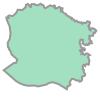

In [9]:
# ✅ Extract shapely geometry (not wrapped)
roi_shape = roi_gdf.geometry.iloc[0]
roi_shape

In [11]:
# Define the start year and end year
start_year = '2020-10'
end_year = '2021-04'

In [17]:
#Create a query object
query = {
    'geopolygon': roi_shape,
    'resolution': (-10, 10),
    'output_crs':'EPSG:4326',
    'time': (start_year, end_year),
    'dask_chunks':{'time':10,'x':200,'y':200}
}

In [25]:
ds = dc.load(product='s2_l2a', **query)
ds

AssertionError: 